In [1]:
import matplotlib
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
import boule as bl
import pandas as pd
import lonlat_labels as label
import cartopy.crs as ccrs
from pathlib import Path
from plot_boundary import plot_boundaries_folder_on_ax

In [2]:
PROJECT_ROOT = Path.cwd().parent
pkl_file=PROJECT_ROOT/"result/run_approach.pkl"

with open(pkl_file, "rb") as f:
    obj = pickle.load(f, encoding="latin1")

    # 提取所需变量并转为 numpy array
    density = np.asarray(obj['densities'])
    reference_levels = np.asarray(obj['reference_levels'])
    score_refden = np.asarray(obj['scores_refden'])
    score_regul = np.asarray(obj['scores_regul'])
    regul = np.asarray(obj['regul_params'])
    regul_residual = np.asarray(obj['regul_residuals'])
    refden_residual = np.asarray(obj['refden_residuals'])

    refden_moho_grid = obj['best_solutions_refden_moho_grid']
    refden_predict_grid = obj['best_solutions_refden_predict_grid']
    observe = obj['observe']
    lon = obj['lon']
    lat = obj['lat']
    lon_sub = obj['lon_sub']
    lat_sub = obj['lat_sub']
    
nlat_moho, nlon_moho = refden_moho_grid.shape
lon_moho = np.linspace(lon.min(), lon.max(), nlon_moho)
lat_moho = np.linspace(lat.min(), lat.max(), nlat_moho)

moho_grid = xr.DataArray(
    refden_moho_grid,  # 如果图东西颠倒或拉伸，改为 refden_moho_grid.T
    dims=("lat", "lon"),
    coords={"lat": lat_moho, "lon": lon_moho}
)

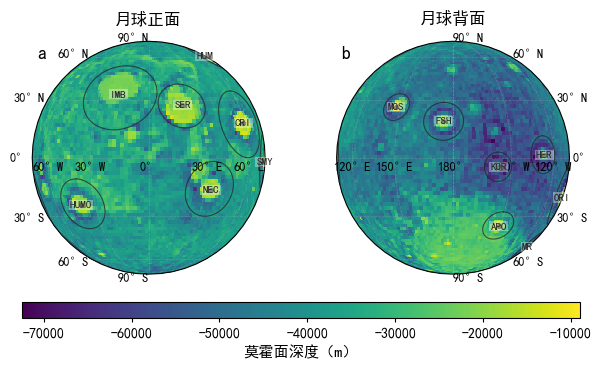

In [3]:
# -----------------------------
# Nature-ish + 中文风格
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["SimHei", "Microsoft YaHei", "Arial", "DejaVu Sans"],
    "axes.unicode_minus": False,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.2,
    "ytick.major.size": 3.2,
    "xtick.direction": "out",
    "ytick.direction": "out",

    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

def add_panel_label(ax, s):
    ax.text(
        0.02, 0.98, s,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=13, fontweight="bold"
    )

# -----------------------------
# 数据
# -----------------------------
da = moho_grid
lon = da["lon"].values
lat = da["lat"].values
Z = da.values

v = 450  # 色标上下限

# 颜色图：论文建议 viridis/cividis（比 jet 更规范）
cmap = "viridis"

# -----------------------------
# Figure
# -----------------------------
fig = plt.figure(figsize=(7.2, 3.6))  # 更接近论文双栏宽的比例（可按需要调）

# ===== 正面 =====
ax1 = plt.subplot(1, 2, 1, projection=ccrs.Orthographic(central_longitude=0, central_latitude=0))
ax1.set_global()

pm1 = ax1.pcolormesh(
    lon, lat, Z,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap=cmap,
    #vmin=-v, vmax=v
)

# 网格线更淡、更细
ax1.gridlines(
    xlocs=np.arange(-180, 181, 30),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.5, alpha=0.35, linestyle="--"
)

ax1.set_title("月球正面", y=1.04)
add_panel_label(ax1, "a")

# ===== 背面 =====
ax2 = plt.subplot(1, 2, 2, projection=ccrs.Orthographic(central_longitude=180, central_latitude=0))
ax2.set_global()

pm2 = ax2.pcolormesh(
    lon, lat, Z,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap=cmap,
    #vmin=-v, vmax=v
)

ax2.gridlines(
    xlocs=np.arange(-180, 181, 30),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.5, alpha=0.35, linestyle="--"
)

ax2.set_title("月球背面", y=1.04)
add_panel_label(ax2, "b")

# -----------------------------
# Colorbar（更简洁、论文风）
# -----------------------------
cbar = fig.colorbar(
    pm1, ax=[ax1, ax2],
    orientation="horizontal",
    pad=0.10, fraction=0.06, aspect=35
)
cbar.set_label("莫霍面深度（m）")

# colorbar 刻度更克制（可选）
# cbar.set_ticks([-450, -300, -150, 0, 150, 300, 450])

# -----------------------------
# 经纬度标注（你原逻辑）
# -----------------------------
xlocs = np.arange(-180, 180, 30)
xlocs = xlocs[(xlocs != 90) & (xlocs != -90)]
ylocs = np.arange(-90, 91, 30)

label.add_lat_labels_on_limb(ax1, ylocs, side="left")
label.add_lon_labels_on_equator(ax1, xlocs)

label.add_lat_labels_on_limb(ax2, ylocs, side="right")
label.add_lon_labels_on_equator(ax2, xlocs, central_lonlat=(180, 0))

# -----------------------------
# 盆地标注（你原逻辑）
# -----------------------------
basins = [
    ("IMB", "Imbrium", 33.0, -18.0, 580),
    ("SER", "Serenitatis", 27.0, 19.0, 370),
    ("CRI", "Crisium", 17.5, 58.5, 530),
    ("SMY", "Smythii", -2.0, 87.0, 420),
    ("HUM", "Humboldtianum", 61.0, 84.0, 300),
    ("MOS", "Moscoviense", 26.0, 147.0, 222.5),
    ("FSH", "Freundlich-Sharonov", 18.5, 175.0, 300),
    ("KOR", "Korolev", -4.5, -157.0, 220),
    ("HER", "Hertzsprung", 1.5, -128.5, 285),
    ("ORI", "Orientale", -20.0, -95.0, 465),
    ("HUMO", "Humorum", -24.0, -39.5, 410),
    ("NEC", "Nectaris", -16.0, 34.0, 430),
    ("APO", "Apollo", -36.0, -151.0, 252.5),
    ("MR", "Mendel-Rydberg", -50.0, -94.0, 315),
]

from plot_basins import add_basin
for (abbr, fullname, lat0, lon0, r_km) in basins:
    add_basin(ax1, abbr, lat0, lon0, r_km)
    add_basin(ax2, abbr, lat0, lon0, r_km)

# -----------------------------
# 输出（建议同时存 PDF + PNG）
# -----------------------------
fig.savefig(PROJECT_ROOT/"plotting/figure/空间域_莫霍面深度.png", dpi=600, bbox_inches="tight")
#fig.savefig("空间域反演结果30km_正背面_nature风格.pdf", dpi=600, bbox_inches="tight", transparent=True)

In [4]:
data_file = PROJECT_ROOT/"data/boueguer_frenquency_11km_withoutmoremare_topo_1deg.csv"

df = pd.read_csv(data_file)
lon_raw = np.sort(df['lon'].unique())
lat_raw = np.sort(df['lat'].unique())
nlat = len(np.unique(lat_raw))
nlon = len(np.unique(lon_raw))

topo_grid  = df.pivot(index='lat', columns='lon', values='topo').loc[lat_raw, lon_raw].values
LON, LAT = np.meshgrid(lon_raw, lat_raw) 

In [5]:
arr = topo_grid + bl.Moon2015.mean_radius

nlon = arr.shape[1]
half = nlon // 2

arr_shifted = np.hstack([
    arr[:, half:],   # 后一半列
    arr[:, :half]    # 前一半列
])
topo_da = xr.DataArray(
    arr_shifted,  # 如果图东西颠倒或拉伸，改为 refden_moho_grid.T
    dims=("lat", "lon"),
    coords={"lat": lat_raw, "lon": lon_raw}
)

region = [lon_raw.min(), lon_raw.max(), lat_raw.min(), lat_raw.max()]

topo_da=topo_da.interp_like(moho_grid)

crustthick=topo_da-moho_grid
crustthick_neg = crustthick.where(crustthick >= 0)

In [6]:
crustthick_neg.values=crustthick_neg.values*0.001
crustthick_neg

<xarray.DataArray (lat: 90, lon: 180)> Size: 130kB
array([[41.66390445, 41.77938985, 41.89133668, ..., 41.28662892,
        41.41848819, 41.54392127],
       [29.62085868, 30.24655749, 30.77765797, ..., 28.83250991,
        28.81844943, 29.09078843],
       [32.61733804, 32.10548305, 31.90429551, ..., 35.38985515,
        34.92193419, 33.62890162],
       ...,
       [43.60476455, 43.17349203, 43.07351716, ..., 43.22164848,
        43.61077457, 43.90450573],
       [42.63324373, 42.27971662, 41.97723165, ..., 43.5520821 ,
        43.38266113, 43.03967142],
       [38.33107802, 38.4703493 , 38.54852897, ..., 37.72530042,
        37.93352115, 38.14420187]], shape=(90, 180))
Coordinates:
  * lat      (lat) float64 720B -89.5 -87.5 -85.5 -83.5 ... 82.5 84.5 86.5 88.5
  * lon      (lon) float64 1kB -179.5 -177.5 -175.5 -173.5 ... 174.5 176.5 178.5

最大: 76.04418228668452 @ -135.50000122905027 0.5
最小: 5.947169638633142 @ 146.49999089385477 24.5


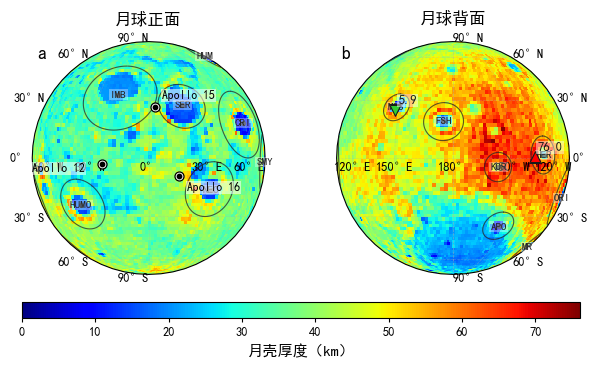

In [ ]:
# -----------------------------
# Nature-ish + 中文风格（统一）
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["SimHei", "Microsoft YaHei", "Arial", "DejaVu Sans"],
    "axes.unicode_minus": False,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.direction": "out",
    "ytick.direction": "out",

    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

def add_panel_label(ax, s):
    ax.text(
        0.02, 0.98, s,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=13, fontweight="bold"
    )

# -----------------------------
# 数据
# -----------------------------
da=crustthick_neg

lon = da["lon"].values
lat = da["lat"].values
Z = da.values

# 色标范围：厚度一般 >=0，建议这样
v = float(np.nanmax(Z))

# -----------------------------
# 图尺寸（论文友好）
# -----------------------------
fig = plt.figure(figsize=(7.2, 3.6))

# ============================
# 正面
# ============================
ax1 = plt.subplot(1, 2, 1, projection=ccrs.Orthographic(central_longitude=0, central_latitude=0))
ax1.set_global()

pm1 = ax1.pcolormesh(
    lon, lat, Z,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="jet",
    vmin=0, vmax=v
)

ax1.gridlines(
    xlocs=np.arange(-180, 181, 30),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.5, alpha=0.35, linestyle="--"
)
ax1.set_title("月球正面", y=1.04)
add_panel_label(ax1, "a")

# ============================
# 背面
# ============================
ax2 = plt.subplot(1, 2, 2, projection=ccrs.Orthographic(central_longitude=180, central_latitude=0))
ax2.set_global()

pm2 = ax2.pcolormesh(
    lon, lat, Z,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="jet",
    vmin=0, vmax=v
)

ax2.gridlines(
    xlocs=np.arange(-180, 181, 30),
    ylocs=np.arange(-90, 91, 30),
    linewidth=0.5, alpha=0.35, linestyle="--"
)
ax2.set_title("月球背面", y=1.04)
add_panel_label(ax2, "b")

# -----------------------------
# 色标（更简洁）
# -----------------------------
cbar = fig.colorbar(
    pm1, ax=[ax1, ax2],
    orientation="horizontal",
    pad=0.10, fraction=0.06, aspect=35
)
cbar.set_label("月壳厚度（km）")
cbar.ax.tick_params(labelsize=9)

# -----------------------------
# 经纬度标签（你原逻辑）
# -----------------------------
xlocs = np.arange(-180, 180, 30)
xlocs = xlocs[(xlocs != 90) & (xlocs != -90)]
ylocs = np.arange(-90, 91, 30)

label.add_lat_labels_on_limb(ax1, ylocs, side="left")
label.add_lon_labels_on_equator(ax1, xlocs)

label.add_lat_labels_on_limb(ax2, ylocs, side="right")
label.add_lon_labels_on_equator(ax2, xlocs, central_lonlat=(180, 0))

# -----------------------------
# 盆地：缩写+全称（图上用缩写）
# -----------------------------
basins = [
    ("IMB", "Imbrium", 33.0, -18.0, 580),
    ("SER", "Serenitatis", 27.0, 19.0, 370),
    ("CRI", "Crisium", 17.5, 58.5, 530),
    ("SMY", "Smythii", -2.0, 87.0, 420),
    ("HUM", "Humboldtianum", 61.0, 84.0, 300),
    ("MOS", "Moscoviense", 26.0, 147.0, 222.5),
    ("FSH", "Freundlich-Sharonov", 18.5, 175.0, 300),
    ("KOR", "Korolev", -4.5, -157.0, 220),
    ("HER", "Hertzsprung", 1.5, -128.5, 285),
    ("ORI", "Orientale", -20.0, -95.0, 465),
    ("HUMO", "Humorum", -24.0, -39.5, 410),
    ("NEC", "Nectaris", -16.0, 34.0, 430),
    ("APO", "Apollo", -36.0, -151.0, 252.5),
    ("MR", "Mendel-Rydberg", -50.0, -94.0, 315),
]

# 盆地线更细、更淡；n_samples 降一点会更快（论文观感差不多）
for (abbr, fullname, lat0, lon0, r_km) in basins:
    add_basin(ax1, abbr, lat0, lon0, r_km, lw=0.8, alpha=0.75, n_samples=180)
    add_basin(ax2, abbr, lat0, lon0, r_km, lw=0.8, alpha=0.75, n_samples=180)

# -----------------------------
# 极值点（全局最大/最小）
# -----------------------------
mask = np.isfinite(Z)

# 最大
imax = np.nanargmax(np.where(mask, Z, np.nan))
ilat_max, ilon_max = np.unravel_index(imax, Z.shape)
lat_max = float(lat[ilat_max])
lon_max = float(lon[ilon_max])
val_max = float(Z[ilat_max, ilon_max])

# 最小
imin = np.nanargmin(np.where(mask, Z, np.nan))
ilat_min, ilon_min = np.unravel_index(imin, Z.shape)
lat_min = float(lat[ilat_min])
lon_min = float(lon[ilon_min])
val_min = float(Z[ilat_min, ilon_min])

print("最大:", val_max, "@", lon_max, lat_max)
print("最小:", val_min, "@", lon_min, lat_min)

def mark_extreme(ax, lon0, lat0, value, marker, color, text_dx=2.0, text_dy=2.0):
    # 标记点（不那么夸张，更论文）
    ax.scatter(
        [lon0], [lat0],
        transform=ccrs.PlateCarree(),
        s=70,
        marker=marker,
        facecolor=color,
        edgecolor="0.1",
        linewidth=0.8,
        zorder=10
    )

    # 数值标注（稍微偏移，避免压在点上）
    ax.text(
        lon0 + text_dx, lat0 + text_dy,
        f"{value:.1f}",
        transform=ccrs.PlateCarree(),
        fontsize=9,
        ha="left", va="bottom",
        color="0.1",
        bbox=dict(facecolor="white", alpha=0.45, edgecolor="none", pad=0.8),
        zorder=11
    )

apollo_sites = {
    "Apollo 12": {"lat": -3.01, "lon": -23.42},
    "Apollo 15": {"lat": 26.13, "lon": 3.63},
    "Apollo 16": {"lat": -8.97, "lon": 15.50},
}
label.plot_apollo_sites(ax1, apollo_sites, show_labels=True)

# 如果你只想在“对应半球可见处”标记，可以再加可见性判断；
# 这里先按你的需求：两幅图都标出来（即使在背面会不可见/贴边）
mark_extreme(ax1, lon_max, lat_max, val_max, "^", "red")
mark_extreme(ax1, lon_min, lat_min, val_min, "v", "limegreen")
mark_extreme(ax2, lon_max, lat_max, val_max, "^", "red")
mark_extreme(ax2, lon_min, lat_min, val_min, "v", "limegreen")
folder_path=PROJECT_ROOT/"plotting/data"
plot_boundaries_folder_on_ax(ax1, folder_path, thick_keywords=("SPATU", "MTU"),linewidth_thick=1.2,linewidth_thin=0.6)
plot_boundaries_folder_on_ax(ax2, folder_path, thick_keywords=("SPATU", "MTU"),linewidth_thick=1.2,linewidth_thin=0.6)
# -----------------------------
# 保存（推荐 png+pdf）
# -----------------------------
fig.savefig(PROJECT_ROOT/"plotting/figure/空间域_月壳厚度.png", dpi=600, bbox_inches="tight")
#fig.savefig("月壳厚度_正背面_中文_nature风格.pdf", dpi=600, bbox_inches="tight", transparent=True)

plt.show()

In [13]:
PROJECT_ROOT

WindowsPath('e:/Moho/all_code_for_github')

In [8]:
apollo_sites = {
    "Apollo 12": (-3.01, -23.42),
    "Apollo 15": (26.13, 3.63),
    "Apollo 16": (-8.97, 15.50),
}

apollo_values = {}

for name, (lat0, lon0) in apollo_sites.items():

    val = da.interp(
        lat=lat0,
        lon=lon0,
        method="linear"
    ).item()

    apollo_values[name] = val

    print(f"{name}: {val:.2f} km")
    

Apollo 12: 33.49 km
Apollo 15: 34.89 km
Apollo 16: 43.40 km


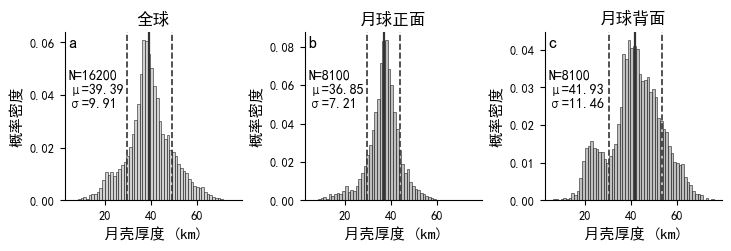

Saved: e:\Moho\all_code_for_github\plotting\figure\空间域_直方图1.png
Saved: e:\Moho\all_code_for_github\plotting\figure\空间域_直方图1.pdf


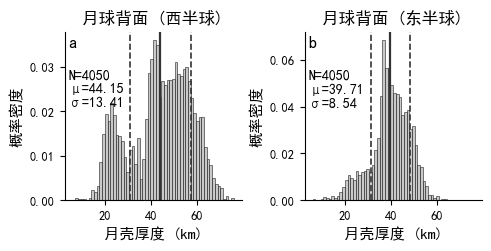

Saved: e:\Moho\all_code_for_github\plotting\figure\空间域_直方图2.png
Saved: e:\Moho\all_code_for_github\plotting\figure\空间域_直方图2.pdf


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Nature-ish 全局风格设置
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["SimHei", "Microsoft YaHei", "Arial", "DejaVu Sans"],  # Arial优先；没装就用DejaVu；中文备用SimHei
    "axes.unicode_minus": False,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# -----------------------------
# 分组数据（你的原逻辑）
# -----------------------------
Z_all = Z.ravel()
Z_all = Z_all[np.isfinite(Z_all)]

Lon2d = np.broadcast_to(lon[None, :], Z.shape)

near_mask = (Lon2d >= -90) & (Lon2d <= 90)
far_mask = ~near_mask

Z_near = Z[near_mask]
Z_far  = Z[far_mask]
Z_near = Z_near[np.isfinite(Z_near)]
Z_far  = Z_far[np.isfinite(Z_far)]

far_west_mask = (Lon2d >= -180) & (Lon2d <= -90)
far_east_mask = (Lon2d >= 90) & (Lon2d < 180)

Z_far_west = Z[far_west_mask]
Z_far_east = Z[far_east_mask]
Z_far_west = Z_far_west[np.isfinite(Z_far_west)]
Z_far_east = Z_far_east[np.isfinite(Z_far_east)]

# -----------------------------
# 统一 bins（可比）
# -----------------------------
bins = 60
vmin = np.nanmin(Z_all)
vmax = np.nanmax(Z_all)
bin_edges = np.linspace(vmin, vmax, bins + 1)

# -----------------------------
# 小工具：面板标注 a/b/c...
# -----------------------------
def add_panel_label(ax, s):
    ax.text(
        0.02, 0.98, s,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=12, fontweight="bold"
    )

# -----------------------------
# 绘图函数（Nature-ish）
# -----------------------------
def plot_hist(ax, data, title, hist_color="0.6", line_color="0.2"):
    mu = np.mean(data)
    sigma = np.std(data)

    # 归一化直方图（概率密度）
    ax.hist(
        data,
        bins=bin_edges,
        density=True,
        color=hist_color,
        alpha=0.70,
        edgecolor="0.15",
        linewidth=0.6,
    )

    # μ 实线；±σ 虚线
    ax.axvline(mu, color=line_color, linewidth=1.6, linestyle="-")
    ax.axvline(mu - sigma, color=line_color, linewidth=1.2, linestyle="--")
    ax.axvline(mu + sigma, color=line_color, linewidth=1.2, linestyle="--")

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("月壳厚度 (km)", fontsize=11)
    ax.set_ylabel("概率密度", fontsize=11)

    # 更干净：去掉上/右边框（Nature 常见）
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # 文字标注（别太大，避免抢画面）
    ax.text(
        0.02, 0.78,
        f"N={data.size}\nμ={mu:.2f}\nσ={sigma:.2f}",
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=10
    )

# -----------------------------
# Figure 1：3张（全局/正/背）
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.4), constrained_layout=True)
# Nature 单栏宽常见 85 mm ≈ 3.35 in；双栏 ~180 mm ≈ 7.1 in
# 这里用 7.2 in 做横向三联图，偏双栏宽

plot_hist(axes[0], Z_all,  "全球",   hist_color="0.75")
plot_hist(axes[1], Z_near, "月球正面", hist_color="0.65")
plot_hist(axes[2], Z_far,  "月球背面",  hist_color="0.65")

add_panel_label(axes[0], "a")
add_panel_label(axes[1], "b")
add_panel_label(axes[2], "c")

out_png = PROJECT_ROOT/"plotting/figure/空间域_直方图1.png"
out_pdf = PROJECT_ROOT/"plotting/figure/空间域_直方图1.pdf"

fig.savefig(out_png, dpi=600)              # Nature 常见要求高分辨率
fig.savefig(out_pdf, dpi=600, transparent=True)
plt.show()
print(f"Saved: {out_png}")
print(f"Saved: {out_pdf}")

# -----------------------------
# Figure 2：背月面东西两半球（2张）
# -----------------------------
fig2, axes2 = plt.subplots(1, 2, figsize=(4.8, 2.4), constrained_layout=True)

plot_hist(axes2[0], Z_far_west, "月球背面 (西半球)", hist_color="0.70")
plot_hist(axes2[1], Z_far_east, "月球背面 (东半球)", hist_color="0.70")

add_panel_label(axes2[0], "a")
add_panel_label(axes2[1], "b")

out_png2 = PROJECT_ROOT/"plotting/figure/空间域_直方图2.png"
out_pdf2 = PROJECT_ROOT/"plotting/figure/空间域_直方图2.pdf"

fig2.savefig(out_png2, dpi=600)
fig2.savefig(out_pdf2, dpi=600, transparent=True)
plt.show()
print(f"Saved: {out_png2}")
print(f"Saved: {out_pdf2}")

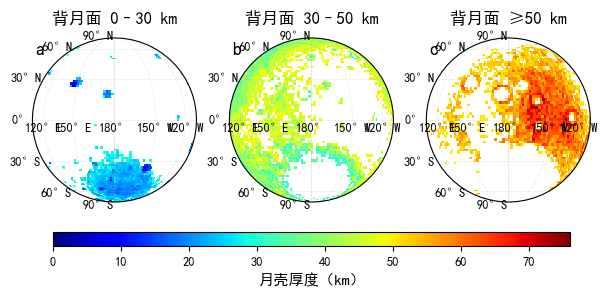

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import lonlat_labels as label

# -----------------------------
# Nature-ish 中文风格
# -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["SimHei", "Microsoft YaHei", "Arial", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
})

def add_panel_label(ax, s):
    ax.text(
        0.02, 0.98, s,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=13, fontweight="bold"
    )

# -----------------------------
# 数据
# -----------------------------
lon = da["lon"].values
lat = da["lat"].values
Z   = da.values

Lon2d = np.broadcast_to(lon[None, :], Z.shape)
far_mask = (Lon2d < -90) | (Lon2d > 90)

mask1 = far_mask & (Z >= 0)  & (Z < 30)
mask2 = far_mask & (Z >= 30) & (Z < 50)
mask3 = far_mask & (Z >= 50)

Z1 = np.where(mask1, Z, np.nan)
Z2 = np.where(mask2, Z, np.nan)
Z3 = np.where(mask3, Z, np.nan)

vmin, vmax = 0, np.nanmax(Z)

# -----------------------------
# 三联图
# -----------------------------
fig = plt.figure(figsize=(7.2, 3.2))
proj = ccrs.Orthographic(central_longitude=180, central_latitude=0)

titles = ["背月面 0–30 km",
          "背月面 30–50 km",
          "背月面 ≥50 km"]

Z_list = [Z1, Z2, Z3]
axes = []

for i, (Zi, title) in enumerate(zip(Z_list, titles), start=1):
    ax = fig.add_subplot(1, 3, i, projection=proj)
    ax.set_global()

    pm = ax.pcolormesh(
        lon, lat, Zi,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="jet",
        vmin=vmin,
        vmax=vmax
    )

    ax.gridlines(
        xlocs=np.arange(-180, 181, 30),
        ylocs=np.arange(-90, 91, 30),
        linewidth=0.5,
        alpha=0.3,
        linestyle="--"
    )

    ax.set_title(title, y=1.04)
    add_panel_label(ax, chr(96 + i))  # a,b,c

    axes.append(ax)

# -----------------------------
# 经纬度标注（只在第一幅加）
# -----------------------------
xlocs = np.arange(-180, 180, 30)
xlocs = xlocs[(xlocs != 90) & (xlocs != -90)]
ylocs = np.arange(-90, 91, 30)

label.add_lat_labels_on_limb(axes[0], ylocs, side="left")
label.add_lon_labels_on_equator(axes[0], xlocs, central_lonlat=(180, 0))

label.add_lat_labels_on_limb(axes[1], ylocs, side="left")
label.add_lon_labels_on_equator(axes[1], xlocs, central_lonlat=(180, 0))

label.add_lat_labels_on_limb(axes[2], ylocs, side="left")
label.add_lon_labels_on_equator(axes[2], xlocs, central_lonlat=(180, 0))

# -----------------------------
# 共用色标
# -----------------------------
cbar = fig.colorbar(
    pm,
    ax=axes,
    orientation="horizontal",
    pad=0.12,
    fraction=0.06,
    aspect=35
)
cbar.set_label("月壳厚度（km）")
cbar.ax.tick_params(labelsize=9)

fig.savefig(PROJECT_ROOT/"plotting/figure/空间域_背月面_三厚度区间.png",
            dpi=600, bbox_inches="tight")
# fig.savefig(PROJECT_ROOT/"plotting/figure/背月面_三厚度区间_正射投影_nature风格.pdf", dpi=600, bbox_inches="tight", transparent=True)

plt.show()